# EDA - Ocorrencias Criminais (CompStat Rio)

Este notebook explora o dataset de **ocorrencias criminais** (`df_ocorrencias_tratado - Extracao 1 .csv`), uma das cinco fontes integradas pelo CompStat Rio para suportar operacoes da Forca Municipal (FM) em 22 areas prioritarias da cidade do Rio de Janeiro.

**Escopo dos dados:** 115.354 registros de roubos (transeunte, celular, em coletivo) entre 2020 e 2024, com geolocalizacao (lat/long, WKT) e atribuicao territorial (AISP/RISP da PMERJ, logradouro).

**O que vamos explorar:**
1. Esquema, qualidade e cobertura temporal.
2. Volume por ano e por tipo de delito (variacao YoY).
3. Concentracao por AISP / RISP.
4. Top logradouros (ruas mais quentes).
5. Distribuicao geografica.
6. Sobreposicao com as 8 areas da Forca Municipal (shapefile EPSG:4326).
7. Takeaways operacionais.


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

REPO = '/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio'
CSV_PATH = f'{REPO}/dados/df_ocorrencias_tratado - Extracao 1 .csv'
SHP_PATH = f'{REPO}/sh_area_forca/areas_forca_municipal.shp'

# The filename uses 'Extração' with accent; resolve robustly:
import glob
matches = glob.glob(f'{REPO}/dados/df_ocorrencias_tratado*.csv')
CSV_PATH = matches[0] if matches else CSV_PATH
print('CSV:', CSV_PATH)
print('SHP:', SHP_PATH)


CSV: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/df_ocorrencias_tratado - Extração 1 .csv
SHP: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/sh_area_forca/areas_forca_municipal.shp


## 2. Carregamento e esquema

Carregamos o CSV e inspecionamos forma, tipos, primeiras linhas e mapa de valores faltantes. Atencao: as colunas `data`, `hora` e `dia_semana` estao em sua maioria **vazias** - a granularidade temporal real e `ano` + `mes`.

In [2]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.dtypes


Shape: (115354, 14)
Out[0]: 
id_criptografado        str
ano                   int64
data                    str
mes                   int64
hora                    str
delito                int64
longitude           float64
latitude            float64
desc_delito             str
aisp                  int64
risp                  int64
locf                    str
dia_semana              str
geometria               str
dtype: object


id_criptografado        str
ano                   int64
data                    str
mes                   int64
hora                    str
delito                int64
longitude           float64
latitude            float64
desc_delito             str
aisp                  int64
risp                  int64
locf                    str
dia_semana              str
geometria               str
dtype: object

In [3]:
df.head()

Out[0]: 
                                    id_criptografado   ano data  mes hora  \
0  0259749088cab44c49ca762835e830a0edd6fedb64ce14...  2023  NaN    5  NaN   
1  70af7ad098e687d1c8672eb108709ac2521a5fa763622a...  2021  NaN   12  NaN   
2  69abf67716dbf941722a0cc66145629b358a0bca240586...  2022  NaN    8  NaN   
3  89bdd094dbf38a61e46f5b753d1ac7d8e06cac9db8f43c...  2022  NaN    3  NaN   
4  ce89e031b4ce0f08cfdf30b5d74bfca7deaa95e0ab2c3d...  2023  NaN    4  NaN   

   delito  longitude   latitude         desc_delito  aisp  risp  \
0      15 -43.267676 -22.862878  Roubo a transeunte    16     1   
1      15 -43.177214 -22.908850  Roubo a transeunte     5     1   
2      15 -43.178471 -22.964581  Roubo a transeunte    19     1   
3      15 -43.219676 -22.983867  Roubo a transeunte    23     1   
4      15 -43.354368 -22.803981  Roubo a transeunte    41     2   

                           locf dia_semana                         geometria  
0                     Rua arapa        NaN  PO

,id_criptografado,ano,data,mes,hora,delito,longitude,latitude,desc_delito,aisp,risp,locf,dia_semana,geometria
0,0259749088cab44c49ca762835e830a0edd6fedb64ce14...,2023,NaN,5,NaN,15,-43.267676,-22.862878,Roubo a transeunte,16,1,Rua arapa,NaN,POINT(-43.26767616 -22.86287837)
1,70af7ad098e687d1c8672eb108709ac2521a5fa763622a...,2021,NaN,12,NaN,15,-43.177214,-22.908850,Roubo a transeunte,5,1,Avenida treze de maio,NaN,POINT(-43.17721362 -22.90884995)
2,69abf67716dbf941722a0cc66145629b358a0bca240586...,2022,NaN,8,NaN,15,-43.178471,-22.964581,Roubo a transeunte,19,1,Rua duvivier,NaN,POINT(-43.17847063 -22.96458062)
3,89bdd094dbf38a61e46f5b753d1ac7d8e06cac9db8f43c...,2022,NaN,3,NaN,15,-43.219676,-22.983867,Roubo a transeunte,23,1,Avenida ataulfo de paiva,NaN,POINT(-43.21967599 -22.98386735)
4,ce89e031b4ce0f08cfdf30b5d74bfca7deaa95e0ab2c3d...,2023,NaN,4,NaN,15,-43.354368,-22.803981,Roubo a transeunte,41,2,Avenida sargento de milicias,NaN,POINT(-43.35436847 -22.80398115)


In [4]:
missing = df.isna().sum().to_frame('n_missing')
missing['pct'] = (missing['n_missing'] / len(df) * 100).round(2)
missing.sort_values('n_missing', ascending=False)


Out[0]: 
                  n_missing   pct
geometria                36  0.03
data                     22  0.02
hora                     22  0.02
dia_semana               22  0.02
locf                      5  0.00
id_criptografado          0  0.00
ano                       0  0.00
mes                       0  0.00
delito                    0  0.00
longitude                 0  0.00
latitude                  0  0.00
desc_delito               0  0.00
aisp                      0  0.00
risp                      0  0.00


,n_missing,pct
geometria,36,0.03
data,22,0.02
hora,22,0.02
dia_semana,22,0.02
locf,5,0.00
id_criptografado,0,0.00
ano,0,0.00
mes,0,0.00
delito,0,0.00
longitude,0,0.00


Confirmado: `data`, `hora`, `dia_semana` praticamente nao tem valores. Vamos descarta-las e trabalhar com `ano` + `mes`.

In [5]:
# Build a proper monthly date for time-series
df['ano'] = pd.to_numeric(df['ano'], errors='coerce').astype('Int64')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce').astype('Int64')
df = df.dropna(subset=['ano', 'mes']).copy()
df['ano_mes'] = pd.to_datetime(dict(year=df['ano'].astype(int), month=df['mes'].astype(int), day=1))
print('Periodo:', df['ano_mes'].min().date(), '->', df['ano_mes'].max().date())
print('Linhas validas apos limpeza temporal:', len(df))


Periodo: 2020-01-01 -> 2024-12-01
Linhas validas apos limpeza temporal: 115354


## 3. Volume por ano e por tipo de delito

Total de ocorrencias por ano e quebra por `delito`. Tambem calculamos variacao percentual ano-a-ano (YoY).

In [6]:
yearly = df.groupby('ano').size().rename('ocorrencias').to_frame()
yearly['yoy_pct'] = yearly['ocorrencias'].pct_change().mul(100).round(2)
yearly


Out[0]: 
      ocorrencias  yoy_pct
ano                       
2020        26870      NaN
2021        25931    -3.49
2022        21890   -15.58
2023        18077   -17.42
2024        22586    24.94


,ocorrencias,yoy_pct
ano,,
2020,26870,NaN
2021,25931,-3.49
2022,21890,-15.58
2023,18077,-17.42
2024,22586,24.94


Volume anual total - visao geral da tendencia.

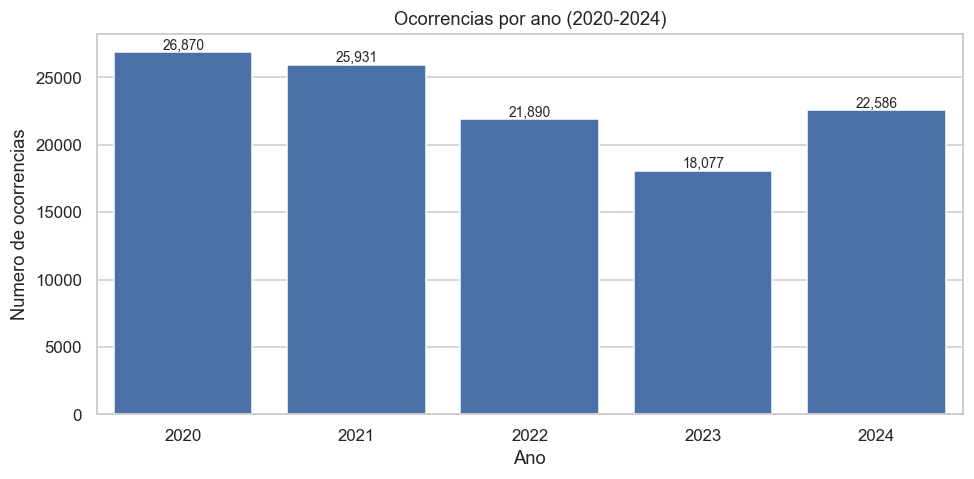

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=yearly.index.astype(int), y=yearly['ocorrencias'], ax=ax, color='#3b6fb6')
for i, v in enumerate(yearly['ocorrencias']):
    ax.text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)
ax.set_title('Ocorrencias por ano (2020-2024)')
ax.set_xlabel('Ano'); ax.set_ylabel('Numero de ocorrencias')
plt.tight_layout(); plt.show()


Quebra por tipo de delito ao longo do tempo (mensal) - mostra a sazonalidade e a participacao dominante do roubo a transeunte.

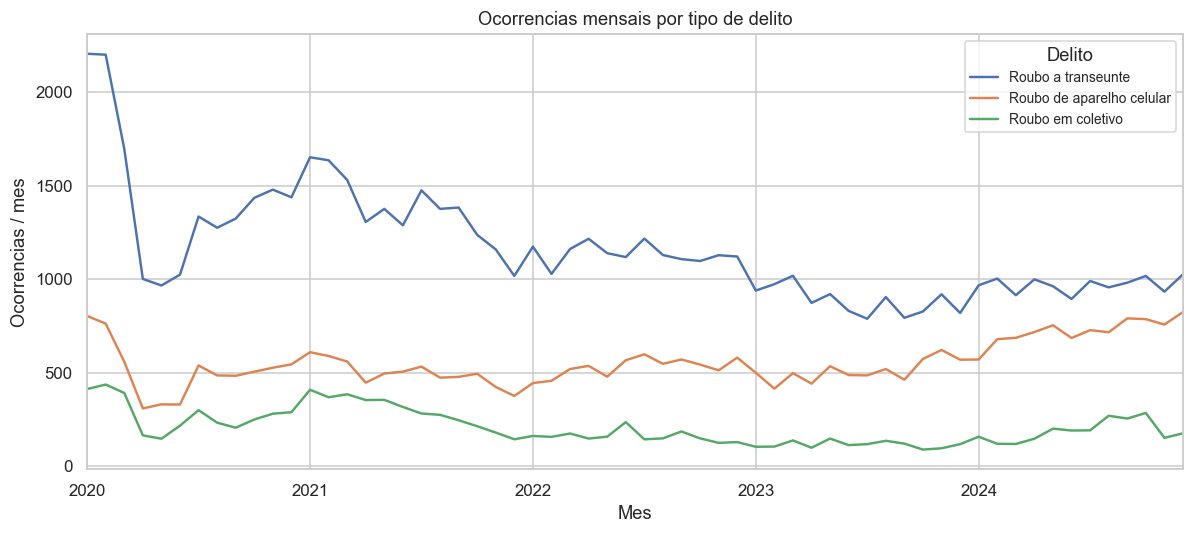

In [8]:
monthly_delito = df.groupby(['ano_mes', 'desc_delito']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(11, 5))
monthly_delito.plot(ax=ax, linewidth=1.6)
ax.set_title('Ocorrencias mensais por tipo de delito')
ax.set_xlabel('Mes'); ax.set_ylabel('Ocorrencias / mes')
ax.legend(title='Delito', loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()


Tabela cruzada ano x delito (volume absoluto).

In [9]:
ct = pd.crosstab(df['ano'], df['desc_delito']).astype(int)
ct['TOTAL'] = ct.sum(axis=1)
ct


Out[0]: 
desc_delito  Roubo a transeunte  Roubo de aparelho celular  Roubo em coletivo  \
ano                                                                             
2020                      17381                       6171               3318   
2021                      16436                       5977               3518   
2022                      13635                       6349               1906   
2023                      10603                       6101               1373   
2024                      11642                       8690               2254   

desc_delito  TOTAL  
ano                 
2020         26870  
2021         25931  
2022         21890  
2023         18077  
2024         22586  


desc_delito,Roubo a transeunte,Roubo de aparelho celular,Roubo em coletivo,TOTAL
ano,,,,
2020,17381,6171,3318,26870
2021,16436,5977,3518,25931
2022,13635,6349,1906,21890
2023,10603,6101,1373,18077
2024,11642,8690,2254,22586


## 4. Top AISPs e RISPs

AISP = Area Integrada de Seguranca Publica (PMERJ). RISP = Regiao Integrada. Mostra a concentracao territorial das ocorrencias do ponto de vista estadual.

In [10]:
top_aisp = df['aisp'].value_counts().head(17)
top_risp = df['risp'].value_counts()
print('AISPs:', df['aisp'].nunique(), '| RISPs:', df['risp'].nunique())
top_aisp


AISPs: 17 | RISPs: 2
Out[0]: 
aisp
3     13656
9     13313
41    11870
5     11379
14     8735
18     8592
6      8218
16     5859
31     5521
2      5394
22     5265
4      4660
19     3418
40     3261
23     2975
27     2296
17      942
Name: count, dtype: int64


aisp
3     13656
9     13313
41    11870
5     11379
14     8735
18     8592
6      8218
16     5859
31     5521
2      5394
22     5265
4      4660
19     3418
40     3261
23     2975
27     2296
17      942
Name: count, dtype: int64

Top AISPs - barras horizontais. As AISPs no topo concentram a maior parte do volume.

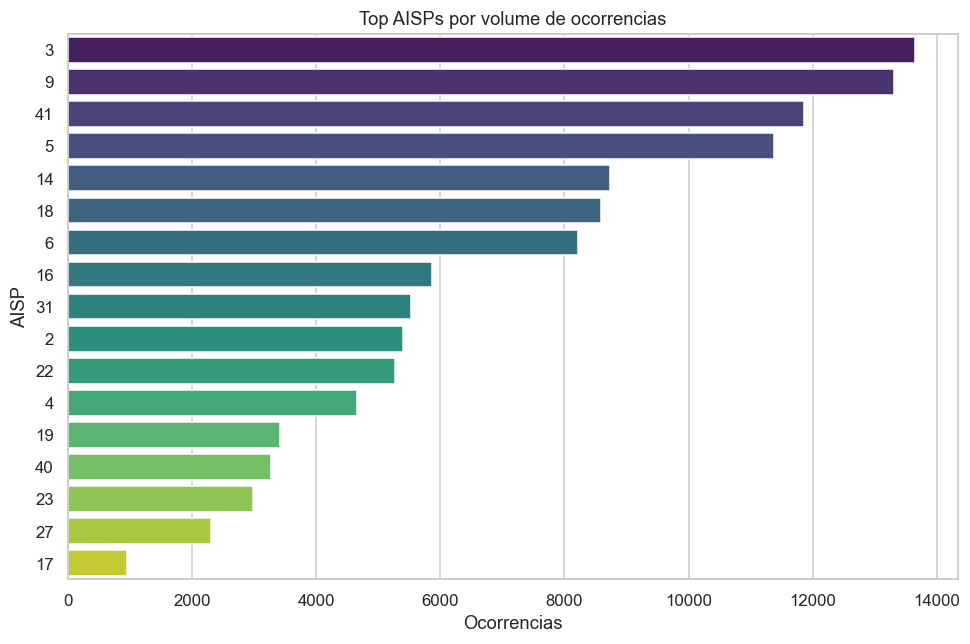

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(y=top_aisp.index.astype(str), x=top_aisp.values, ax=ax,
            palette='viridis', orient='h')
ax.set_title('Top AISPs por volume de ocorrencias')
ax.set_xlabel('Ocorrencias'); ax.set_ylabel('AISP')
plt.tight_layout(); plt.show()


Distribuicao por RISP.

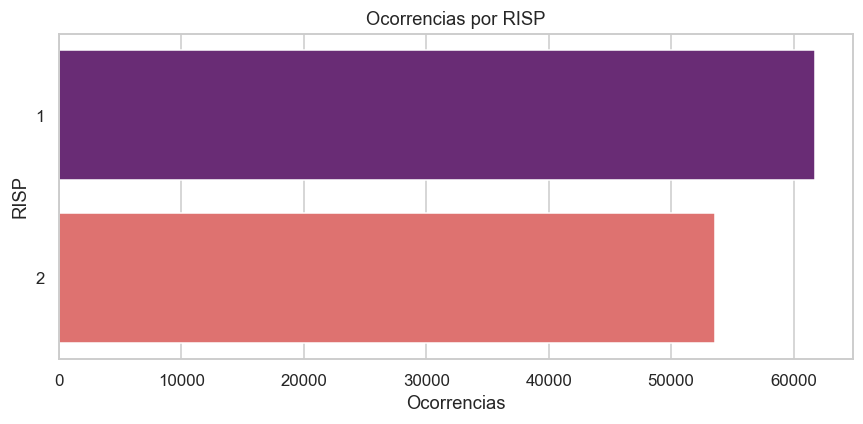

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(y=top_risp.index.astype(str), x=top_risp.values, ax=ax,
            palette='magma', orient='h')
ax.set_title('Ocorrencias por RISP')
ax.set_xlabel('Ocorrencias'); ax.set_ylabel('RISP')
plt.tight_layout(); plt.show()


## 5. Top logradouros (locf)

`locf` e o nome da via em texto livre (lowercased). Os 20 logradouros mais frequentes apontam pontos de atritos urbanos onde a Forca Municipal pode priorizar patrulhamento.

In [13]:
top_streets = (df['locf']
                 .dropna()
                 .str.strip()
                 .replace('', np.nan)
                 .dropna()
                 .value_counts()
                 .head(20))
top_streets


Out[0]: 
locf
Avenida brasil                                   3111
Avenida avenida brasil                           1935
Avenida presidente vargas                        1185
Avenida pastor martin luther king jr.            1175
Avenida das americas                             1106
Avenida avenida presidente vargas                 840
Avenida dom helder camara                         811
Avenida ayrton senna                              655
Avenida avenida pastor martin luther king jr.     595
Avenida avenida atlantica                         557
Avenida avenida das americas                      501
Avenida atlantica                                 490
Avenida mem de sa                                 468
Rua vinte e quatro de maio                        415
Avenida avenida mem de sa                         392
Avenida ministro edgard romero                    391
Rua conselheiro galvao                            385
Rua carolina machado                              376
Avenida rio br

locf
Avenida brasil                                   3111
Avenida avenida brasil                           1935
Avenida presidente vargas                        1185
Avenida pastor martin luther king jr.            1175
Avenida das americas                             1106
Avenida avenida presidente vargas                 840
Avenida dom helder camara                         811
Avenida ayrton senna                              655
Avenida avenida pastor martin luther king jr.     595
Avenida avenida atlantica                         557
Avenida avenida das americas                      501
Avenida atlantica                                 490
Avenida mem de sa                                 468
Rua vinte e quatro de maio                        415
Avenida avenida mem de sa                         392
Avenida ministro edgard romero                    391
Rua conselheiro galvao                            385
Rua carolina machado                              376
Avenida rio branco     

Top 20 logradouros mais quentes.

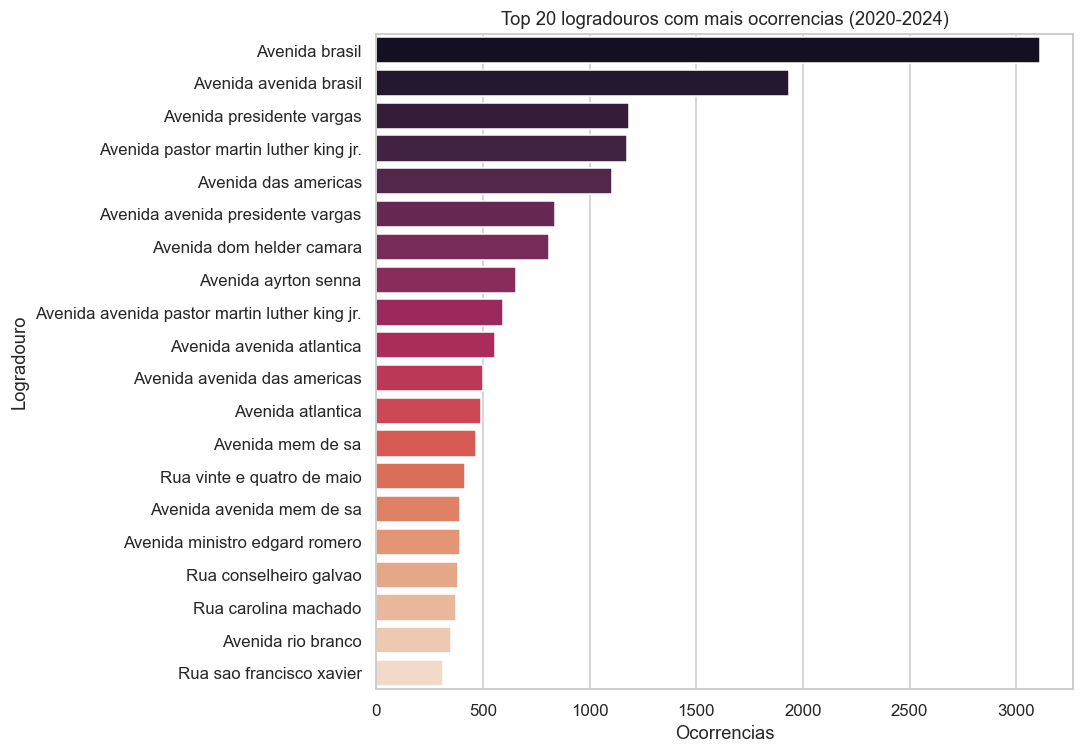

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(y=top_streets.index, x=top_streets.values, ax=ax,
            palette='rocket', orient='h')
ax.set_title('Top 20 logradouros com mais ocorrencias (2020-2024)')
ax.set_xlabel('Ocorrencias'); ax.set_ylabel('Logradouro')
plt.tight_layout(); plt.show()


## 6. Distribuicao geografica

Scatter de lat/long colorido por tipo de delito. Para manter o plot leve, amostramos 20k pontos. Sobrepomos as 8 areas da Forca Municipal (shapefile, EPSG:4326).

In [15]:
# Coerce numeric coords and filter Rio bounding box (sanity)
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
geo = df.dropna(subset=['longitude', 'latitude']).copy()
geo = geo[(geo['longitude'].between(-43.85, -43.10)) &
          (geo['latitude'].between(-23.10, -22.70))]
print('Pontos com geolocalizacao valida no Rio:', len(geo))


Pontos com geolocalizacao valida no Rio: 115318


In [16]:
fm = gpd.read_file(SHP_PATH).to_crs(epsg=4326)
print('Areas FM:', len(fm))
fm[['geometry']].assign(area=fm.iloc[:, 0].astype(str)).head(10)


Areas FM: 8
Out[0]: 
                                            geometry  area
0  POLYGON ((-43.21251 -22.89815, -43.21289 -22.8...   2.0
1  POLYGON ((-43.19636 -22.9525, -43.19578 -22.95...   9.0
2  POLYGON ((-43.21838 -22.98006, -43.21846 -22.9...  10.0
3  POLYGON ((-43.56256 -22.90247, -43.56289 -22.9...  11.0
4  POLYGON ((-43.18037 -22.95593, -43.18092 -22.9...  12.0
5  POLYGON ((-43.18282 -22.94779, -43.18432 -22.9...  14.0
6  POLYGON ((-43.22726 -22.92115, -43.22722 -22.9...  19.0
7  POLYGON ((-43.19672 -22.90662, -43.19642 -22.9...  20.0


,geometry,area
0,"POLYGON ((-43.21251 -22.89815, -43.21289 -22.8...",2.0
1,"POLYGON ((-43.19636 -22.9525, -43.19578 -22.95...",9.0
2,"POLYGON ((-43.21838 -22.98006, -43.21846 -22.9...",10.0
3,"POLYGON ((-43.56256 -22.90247, -43.56289 -22.9...",11.0
4,"POLYGON ((-43.18037 -22.95593, -43.18092 -22.9...",12.0
5,"POLYGON ((-43.18282 -22.94779, -43.18432 -22.9...",14.0
6,"POLYGON ((-43.22726 -22.92115, -43.22722 -22.9...",19.0
7,"POLYGON ((-43.19672 -22.90662, -43.19642 -22.9...",20.0


Mapa de pontos (amostra 20k) com poligonos da Forca Municipal sobrepostos.

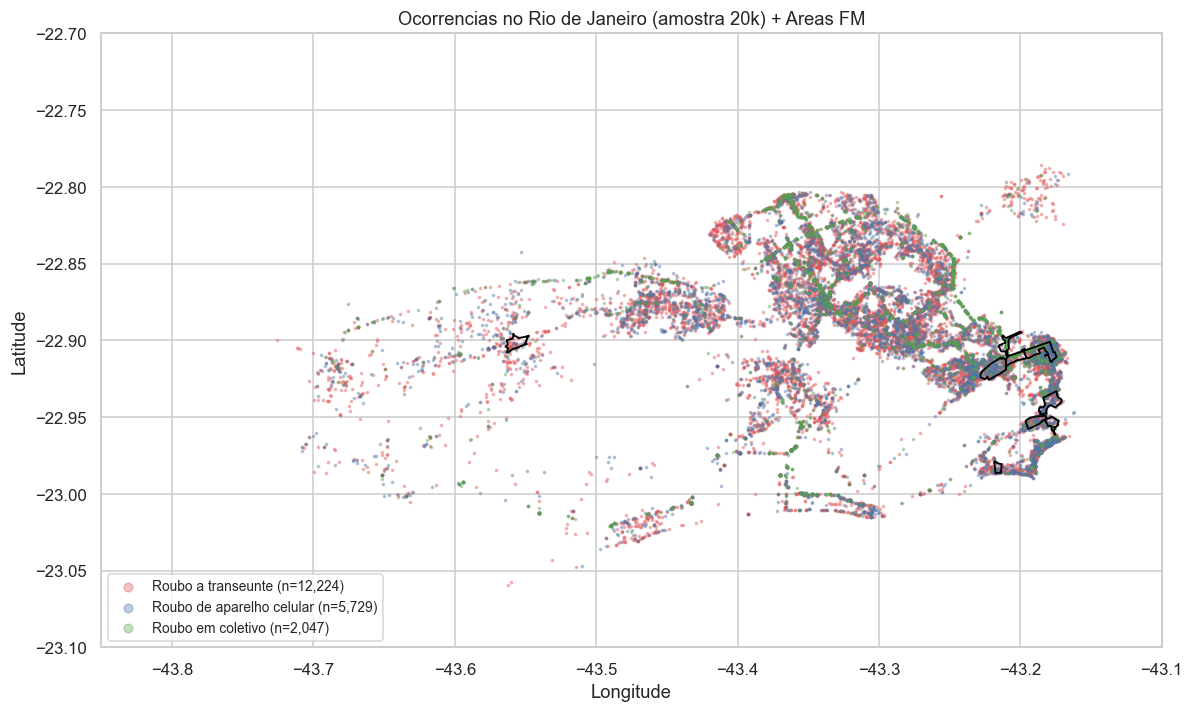

In [17]:
sample = geo.sample(n=min(20000, len(geo)), random_state=42)
fig, ax = plt.subplots(figsize=(11, 9))

palette = {
    'Roubo a transeunte': '#e15759',
    'Roubo de aparelho celular': '#4e79a7',
    'Roubo em coletivo': '#59a14f',
}
for delito, color in palette.items():
    sub = sample[sample['desc_delito'] == delito]
    ax.scatter(sub['longitude'], sub['latitude'], s=2, alpha=0.35,
               c=color, label=f'{delito} (n={len(sub):,})')

fm.boundary.plot(ax=ax, color='black', linewidth=1.2)
# Label FM polygons with the first text-like column we can find
name_col = None
for c in fm.columns:
    if fm[c].dtype == object and c != 'geometry':
        name_col = c; break
if name_col:
    for _, row in fm.iterrows():
        c = row.geometry.centroid
        ax.annotate(str(row[name_col])[:24], (c.x, c.y),
                    fontsize=7, ha='center', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', alpha=0.7))

ax.set_xlim(-43.85, -43.10); ax.set_ylim(-23.10, -22.70)
ax.set_title('Ocorrencias no Rio de Janeiro (amostra 20k) + Areas FM')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower left', markerscale=4, fontsize=9)
plt.tight_layout(); plt.show()


## 7. Ocorrencias por area da Forca Municipal

Spatial join: cada ponto e atribuido ao poligono FM que o contem. Pontos fora de qualquer poligono FM ficam como `FORA_FM`.

In [18]:
gpts = gpd.GeoDataFrame(
    geo,
    geometry=gpd.points_from_xy(geo['longitude'], geo['latitude']),
    crs='EPSG:4326',
)

# Identify a name column on the FM layer
fm_name_col = name_col if name_col else fm.columns[0]
fm_subset = fm[[fm_name_col, 'geometry']].rename(columns={fm_name_col: 'area_fm'})

joined = gpd.sjoin(gpts, fm_subset, how='left', predicate='within')
joined['area_fm'] = joined['area_fm'].fillna('FORA_FM')

per_area = joined['area_fm'].value_counts().rename('ocorrencias').to_frame()
per_area['pct'] = (per_area['ocorrencias'] / per_area['ocorrencias'].sum() * 100).round(2)
per_area


Out[0]: 
         ocorrencias    pct
area_fm                    
FORA_FM       104818  90.89
20.0            4011   3.48
2.0             1974   1.71
19.0            1507   1.31
14.0            1138   0.99
9.0              821   0.71
12.0             457   0.40
10.0             298   0.26
11.0             294   0.25


,ocorrencias,pct
area_fm,,
FORA_FM,104818,90.89
20.0,4011,3.48
2.0,1974,1.71
19.0,1507,1.31
14.0,1138,0.99
9.0,821,0.71
12.0,457,0.40
10.0,298,0.26
11.0,294,0.25


Volume por area FM (excluindo `FORA_FM` para destacar as 8 areas em escopo).

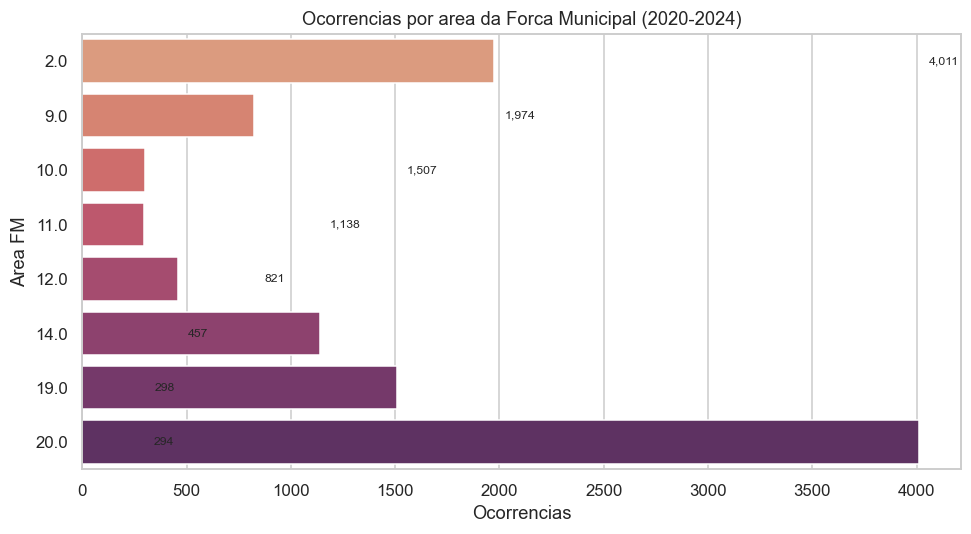

In [19]:
fm_only = per_area.drop(index='FORA_FM', errors='ignore')
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(y=fm_only.index, x=fm_only['ocorrencias'], ax=ax,
            palette='flare', orient='h')
ax.set_title('Ocorrencias por area da Forca Municipal (2020-2024)')
ax.set_xlabel('Ocorrencias'); ax.set_ylabel('Area FM')
for i, v in enumerate(fm_only['ocorrencias']):
    ax.text(v + 50, i, f'{int(v):,}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


Heatmap area FM x tipo de delito - mostra qual area tem qual perfil de criminalidade.

Out[0]: 
desc_delito  Roubo a transeunte  Roubo de aparelho celular  Roubo em coletivo
area_fm                                                                      
2.0                        43.7                       21.0               35.4
9.0                        65.4                       30.5                4.1
10.0                       63.4                       34.9                1.7
11.0                       71.4                       24.5                4.1
12.0                       54.9                       38.3                6.8
14.0                       59.7                       34.3                6.1
19.0                       57.1                       39.6                3.3
20.0                       67.9                       23.5                8.6


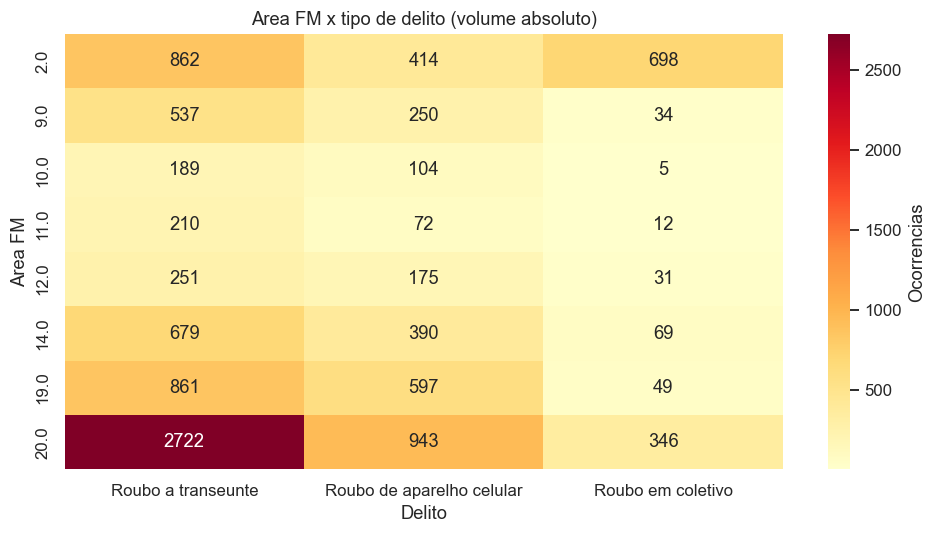

desc_delito,Roubo a transeunte,Roubo de aparelho celular,Roubo em coletivo
area_fm,,,
2.0,43.7,21.0,35.4
9.0,65.4,30.5,4.1
10.0,63.4,34.9,1.7
11.0,71.4,24.5,4.1
12.0,54.9,38.3,6.8
14.0,59.7,34.3,6.1
19.0,57.1,39.6,3.3
20.0,67.9,23.5,8.6


In [20]:
mix = (joined[joined['area_fm'] != 'FORA_FM']
        .groupby(['area_fm', 'desc_delito']).size().unstack(fill_value=0))
mix_pct = mix.div(mix.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(mix, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Ocorrencias'})
ax.set_title('Area FM x tipo de delito (volume absoluto)')
ax.set_xlabel('Delito'); ax.set_ylabel('Area FM')
plt.tight_layout(); plt.show()
mix_pct


Evolucao anual por area FM - quem esta esfriando, quem esta esquentando.

Out[0]: 
area_fm  2.0   9.0   10.0  11.0  12.0  14.0  19.0  20.0
ano                                                    
2020      449   126    56    75    91   196   231   891
2021      434   119    69    58    73   174   251   784
2022      364   144    82    52    82   202   284   803
2023      328   168    52    52    82   200   317   667
2024      399   264    39    57   129   366   424   866


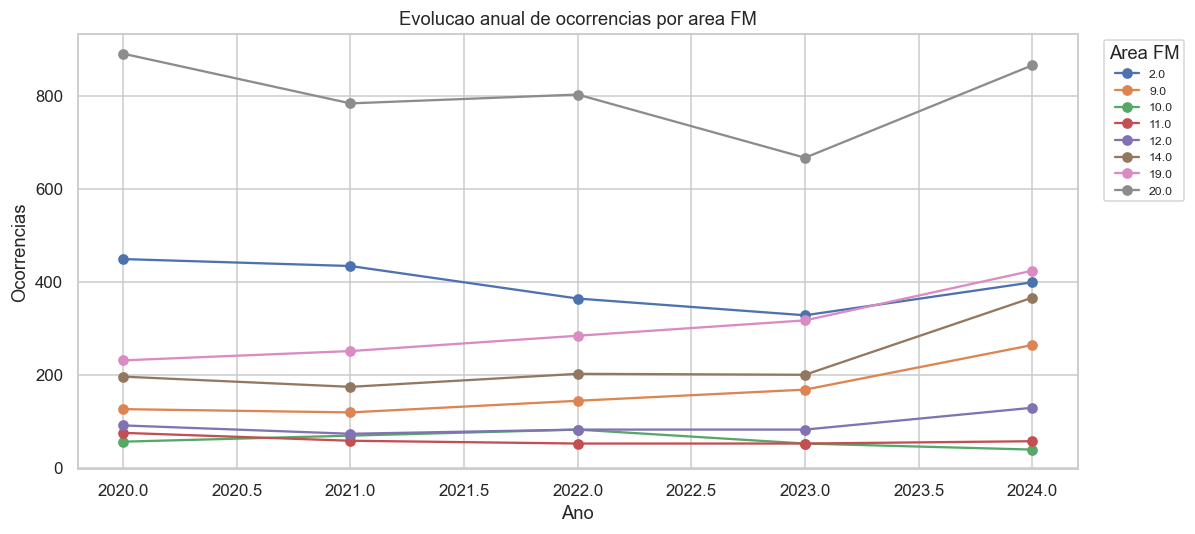

area_fm,2.0,9.0,10.0,11.0,12.0,14.0,19.0,20.0
ano,,,,,,,,
2020,449,126,56,75,91,196,231,891
2021,434,119,69,58,73,174,251,784
2022,364,144,82,52,82,202,284,803
2023,328,168,52,52,82,200,317,667
2024,399,264,39,57,129,366,424,866


In [21]:
trend = (joined[joined['area_fm'] != 'FORA_FM']
          .groupby(['ano', 'area_fm']).size().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(11, 5))
trend.plot(ax=ax, marker='o', linewidth=1.5)
ax.set_title('Evolucao anual de ocorrencias por area FM')
ax.set_xlabel('Ano'); ax.set_ylabel('Ocorrencias')
ax.legend(title='Area FM', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()
trend


## 8. Conclusoes

Principais takeaways desta EDA inicial:

1. **A massa esta em Roubo a transeunte (60.4% do total), Roubo de aparelho celular (28.9%) e Roubo em coletivo (10.7%).** Estrategias de patrulhamento de FM devem calibrar primeiro para transeunte.

2. **Tendencia de queda 2020-2023 com forte rebote em 2024:** 26.870 (2020) -> 25.931 (-3.5%) -> 21.890 (-15.6%) -> 18.077 (-17.4%) -> **22.586 (+24.9%)**. O salto de 2024 merece investigacao prioritaria - pode ser real ou efeito de mudanca de registro.

3. **Concentracao territorial e altissima:** as 5 AISPs do topo (3, 9, 41, 5, 14) somam ~52% das ocorrencias; e o `locf` mostra que **Avenida Brasil sozinha tem 3.111 registros** (mais 1.935 em "Avenida avenida brasil" - duplicacao de prefixo a tratar). Top 10 ruas = sinal acionavel para escala de patrulhamento.

4. **Apenas 9.1% das ocorrencias caem dentro das 8 areas FM com shapefile** - os outros 90.9% estao em `FORA_FM`. Isso e esperado (Rio inteiro vs. 8 poligonos pequenos) mas reforca que **o CompStat de FM cobre uma fatia muito especifica** da criminalidade da cidade. Dentro do escopo FM, a area 20.0 lidera (4.011 ocorrencias, ~38% do volume FM).

5. **Mix de delitos varia por area FM:** area 2.0 tem perfil atipico com **35.4% de roubo em coletivo** (vs. 1.7-8.6% nas outras) - reflete corredor de transporte. Area 11.0 e mais "monocultura" de transeunte (71.4%). Areas 10.0, 12.0, 14.0, 19.0 tem participacao alta de roubo de celular (34-39%).

**Limitacoes do dado:**
- `data`, `hora` e `dia_semana` estao **vazias** - sem cruzamento com `disk_denuncia.csv` nao da pra analisar hora-do-dia ou dia-da-semana.
- `locf` tem **prefixo duplicado** ("Avenida avenida X") em parte dos registros - precisa de limpeza antes de qualquer agregacao confiavel por rua.
- As areas FM no shapefile vem identificadas por **codigo numerico** (2, 9, 10, 11, 12, 14, 19, 20) - precisamos cruzar com a tabela de nomes para mapear para "Rio Sul", "Praia Botafogo" etc.

**Proximos passos sugeridos:**
- Cruzar com `fatores_urbanos.csv` (densidade de cameras, comercio, etc.) para explicar hotspots.
- Cruzar com `disk_denuncia.csv` para recuperar dimensao temporal fina.
- Modelar risco por celula H3/quadrante dentro de cada area FM.
